# Conformal Prediction

Construct prediction regions by comparing a candidate observation with observed conformity scores. Visualize the resulting sets and connect their coverage interpretation with exchangeability and the finite-sample ranking argument.


## Run this tour

Run the cells in order with a Python 3 kernel. The first cell locates the companion data and toolbox and installs missing dependencies when needed. All worked examples include their implementation directly in this notebook. Random seeds make comparisons reproducible; you can change them to explore other samples.


In [1]:
# Locate the companion toolbox locally, or fetch it for a standalone/Colab copy.
from pathlib import Path
import importlib.util
import os
import subprocess
import sys

working = Path.cwd()
candidates = [working, working / "python", working.parent / "python"]
python_dir = next((p for p in candidates if (p / "nt_toolbox").is_dir()), None)
if python_dir is None:
    checkout = working / "numerical-tours-support"
    if not checkout.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "master",
                "https://github.com/gpeyre/numerical-tours.git",
                str(checkout),
            ],
            check=True,
        )
    python_dir = checkout / "python"
os.chdir(python_dir)
if str(python_dir) not in sys.path:
    sys.path.insert(0, str(python_dir))
requirements = python_dir / "requirements.txt"
if any(
    importlib.util.find_spec(name) is None
    for name in [
        "numpy",
        "scipy",
        "matplotlib",
        "skimage",
        "sklearn",
        "pywt",
        "ipywidgets",
        "cvxpy",
        "skfmm",
        "autograd",
        "progressbar",
        "celer",
    ]
):
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-r", str(requirements)], check=True
    )

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "figure.dpi": 100,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
        "image.cmap": "gray",
    }
)
%matplotlib inline

Conformal prediction turns a point predictor into a prediction set with finite-sample marginal coverage under exchangeability. We use polynomial regression as a simple example. The guarantee concerns a new random observation; it does not generally give conditional coverage at every fixed input.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

Generate input data.


In [3]:
def phi0(x):
    return np.concatenate((x * 0 + 1, x, x**2, x**3), axis=1)


n = 200  # number of points
X0 = 8 * (np.random.rand(n, 1) - 0.5) + 0.5
w0 = np.array([0, -5, 0, 1])  # coefficients
Y0 = phi0(X0) @ w0 + np.random.randn(n) * 7

Display data.


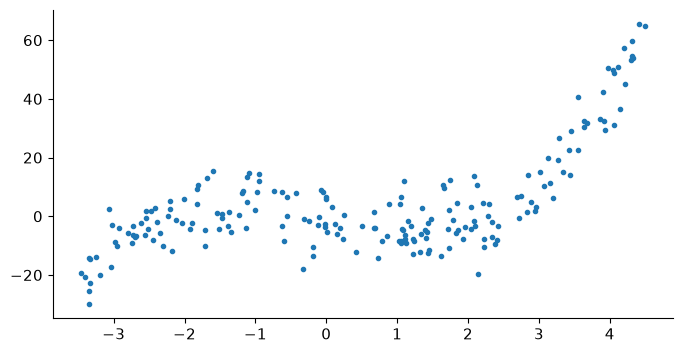

In [4]:
plt.plot(X0, Y0, ".");

We fit a polynomial by least squares. With $\varphi(x)=(1,x,x^2,x^3)$, define
$$\widehat w(X,Y)=\arg\min_w\sum_i |\langle\varphi(x_i),w\rangle-y_i|^2,\qquad \widehat y(x)=\langle\varphi(x),\widehat w\rangle.$$
The fit treats all observations symmetrically, as required by the full conformal construction.


In [5]:
def phi(x):
    return np.concatenate((x * 0 + 1, x, x**2, x**3), axis=1)

Implements $\hat w(x|X,Y)$ and $\hat y(x|X,Y)$.


In [6]:
def hat_w(X, Y):
    return np.linalg.pinv(phi(X)) @ Y


def hat_y(x, w):
    return phi(x) @ w

Display the prediction at the sample of the dataset.


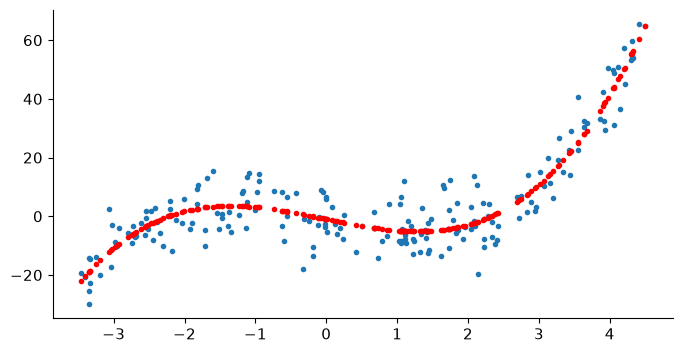

In [7]:
plt.plot(X0, Y0, ".")
plt.plot(X0, hat_y(X0, hat_w(X0, Y0)), "r.");

The nonconformity score is the absolute prediction error,
$$S(x,y;w)=|y-\langle\varphi(x),w\rangle|.$$
A larger score means that the candidate is less compatible with the fitted model.


In [8]:
def S(x, y, w):
    return np.abs(y - hat_y(x, w))

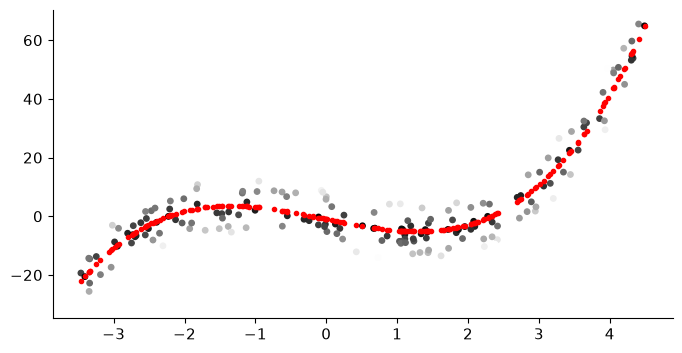

In [9]:
plt.scatter(X0, Y0, c=S(X0, Y0, hat_w(X0, Y0)), s=15, vmax=10)
plt.plot(X0, hat_y(X0, hat_w(X0, Y0)), "r.");

For every candidate $(x,y)$, refit the model on the augmented dataset and compute its score $V$ and the training scores $V_i$ using this same fit. The conformal p-value is
$$p(x,y)=\frac{1+\sum_{i=1}^{n}\mathbf 1\{V_i\geq V\}}{n+1}.$$
The added one counts the candidate itself. Counting ties with $\geq$ makes the coverage statement conservative when scores coincide.


In [10]:
def conformal(x, y):
    X_augmented = np.vstack((X0, [[x]]))
    Y_augmented = np.append(Y0, y)
    w = hat_w(X_augmented, Y_augmented)
    scores = S(X_augmented, Y_augmented, w)
    return (1 + np.count_nonzero(scores[:-1] >= scores[-1])) / len(scores)

For a miscoverage level $\alpha\in(0,1)$, retain the candidates with $p(x,y)>\alpha$:
$$I_\alpha(x)=\{y:p(x,y)>\alpha\}.$$
Under exchangeability and a permutation-invariant fitting rule,
$$\mathbb P\{Y_{n+1}\in I_\alpha(X_{n+1})\}\geq1-\alpha.$$
The set need not be an interval. The finite grid below visualizes an approximation to it; the theorem applies to the full set, not to a truncated plotting window.


Evaluate the conformal p-value on a grid to reveal the shape of the prediction set.


In [11]:
nx = 80
ny = 70
xlist = np.linspace(X0.min(), X0.max(), nx)
ylist = np.linspace(Y0.min(), Y0.max(), ny)
R = np.zeros((nx, ny))
for ix in range(nx):
    for iy in range(ny):
        R[ix, iy] = conformal(xlist[ix], ylist[iy])

The shaded region contains candidates accepted at the 90% marginal coverage level. Its width reflects both the noisy observations and the fitted polynomial.


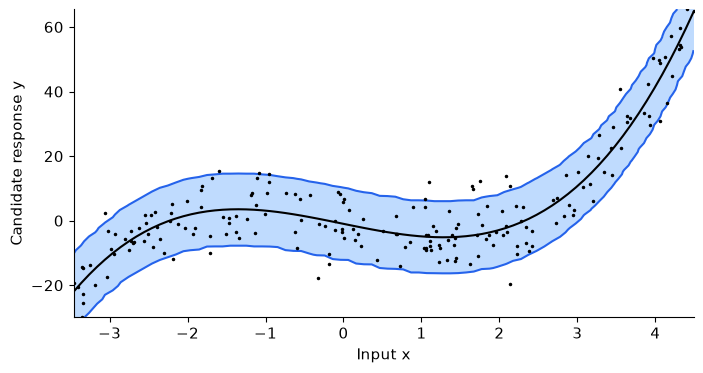

In [12]:
alpha = 0.1
plt.contourf(xlist, ylist, R.T, levels=[alpha, 1], colors=["#bfdbfe"])
plt.contour(xlist, ylist, R.T, levels=[alpha], colors=["#2563eb"])
plt.plot(xlist, hat_y(xlist.reshape(-1, 1), hat_w(X0, Y0)), "k-")
plt.plot(X0, Y0, "k.", markersize=3)
plt.xlabel("Input x")
plt.ylabel("Candidate response y")
assert np.all((R >= 1 / (n + 1)) & (R <= 1))

## References and further reading

- Anastasios N. Angelopoulos and Stephen Bates. [A Gentle Introduction to Conformal Prediction and Distribution-Free Uncertainty Quantification](https://arxiv.org/abs/2107.07511). 2023, Foundations and Trends in Machine Learning 16(4), 494–591. Coverage guarantees, exchangeability, and practical calibration.

- Vladimir Vovk, Alex Gammerman, and Glenn Shafer. [Algorithmic Learning in a Random World](https://doi.org/10.1007/b106715). 2005, Springer. The foundational theory of conformal prediction.

- Glenn Shafer and Vladimir Vovk. [A Tutorial on Conformal Prediction](https://www.jmlr.org/papers/v9/shafer08a.html). 2008, JMLR 9, 371–421. Conformity scores, p-values, and prediction regions.

- Jing Lei et al.. [Distribution-Free Predictive Inference for Regression](https://arxiv.org/abs/1604.04173). 2018, JASA 113(523), 1094–1111. Regression prediction bands and split conformal inference.

- Yaniv Romano, Evan Patterson, and Emmanuel Candès. [Conformalized Quantile Regression](https://arxiv.org/abs/1905.03222). 2019, NeurIPS. Adaptive prediction intervals for heteroscedastic regression.
